# 03 — Sentiment Mismatch Analysis

This notebook starts from the manually tagged candidate dataset and compares two layers of information:

- the original Steam recommendation label
- the manually interpreted sentiment from the review text

The main question is whether the binary Steam label tells the same story as the review text.

The focus is not only on direct contradictions.  
Mixed, ambiguous, meme-like, and low-information reviews are also important because they show where a simple `Recommended` / `Not Recommended` label loses nuance.


## 1. Setup

This notebook uses the filled pilot tagging file from `data/interim/`.

Input:

```text
../data/interim/manual_tagging_candidates_tagged.csv
```

Output:

```text
../data/processed/manual_tagging_analysis_ready.csv
```

The input must already contain the completed `actual_sentiment` and `review_category` labels.

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

DATA_INTERIM = Path("../data/interim")
DATA_PROCESSED = Path("../data/processed")

plt.rcParams["figure.figsize"] = (10, 6)
pd.set_option("display.max_colwidth", 250)


## 2. Load the tagged candidate dataset

At this point, the candidate file should already contain manual labels such as `actual_sentiment` and `review_category`.

I keep the load path simple here so the notebook follows the cleaned project structure directly.


In [4]:
input_path = DATA_INTERIM / "manual_tagging_candidates_tagged.csv"

if not input_path.exists():
    raise FileNotFoundError(
        f"Filled tagging file not found: {input_path}"
    )

df = pd.read_csv(input_path, encoding="utf-8-sig")

print(f"Loaded tagged candidate dataset from: {input_path}")
print("Shape:", df.shape)

df.head()


Loaded tagged candidate dataset from: ..\data\interim\manual_tagging_candidates_tagged.csv
Shape: (38, 20)


,game_title,author_name,review_date,recommendation,playtime_hours,playtime_segment,is_veteran,word_count,helpful_count,funny_count,contains_update_keyword_refined,contains_bug_or_degradation_keyword,contains_positive_emotion,contains_negative_emotion,is_mourning_refined,is_mismatch_candidate,analysis_review,actual_sentiment,review_category,annotation_notes
0,Phasmophobia,Clown,Posted: 12 May,Not Recommended,77.1,Regular,False,17,0,0,True,True,False,True,False,False,Rushed out a buggy and broken update so they could do an Alan Wake (2) collab. Marvelous.,Negative,Update Backlash; Sarcasm / Bug Complaint,"Negative jelas, menyalahkan update dan collab."
1,Phasmophobia,Eggis,Posted: 12 May,Not Recommended,23.5,Casual,False,13,3,0,True,False,False,True,False,False,The latest update has ruined the experience for me ( bendy back gone),Negative,Update Backlash; Mourning-lite,Singkat tapi jelas update ruined experience.
2,Phasmophobia,Tracker,Posted: May 12,Not Recommended,65.4,Regular,False,166,4,0,True,True,True,True,False,False,This last update was a mess. It's been on the roadmap since 2022 yet the devs keep saying it was rushed at every turn. An update that is a flawed mess of so called features. If you like awful AI like animations and a dev team that will lie about ...,Negative,Update Backlash; Developer Criticism,"Kritik update, dev response, gameplay degradation."
3,Phasmophobia,King Chonk,Posted: May 12,Not Recommended,470.5,Hardcore,True,149,0,0,True,True,True,True,False,False,"TL;DR Don't get it yet character customization added animations that made it so sluggish I have played this game for many hours, maybe not as much as some of the community but still enough to enjoy my time with this game, I have been through the ...",Negative,Update Backlash; Bug / Gameplay Degradation,"Veteran/high playtime, tidak recommend karena update."
4,Phasmophobia,Scout,Posted: May 12,Not Recommended,476.6,Hardcore,True,418,3,0,True,True,True,True,False,False,"I used to really love playing this game, but it seems the devs have just been making questionable decisions ever since the item update. Rather than rework maps that no one likes, like school or prison, they reworked a beloved map. I actually like...",Negative,Mourning; Update Backlash,"Strong mourning. Dulu suka, sekarang kecewa."


## 3. Basic validation

Before looking at mismatch patterns, the required columns need to be present and readable.

This step also normalizes a few manual-label variants so that small spelling differences do not split the same category into multiple groups.


In [5]:
required_columns = [
    "recommendation",
    "actual_sentiment",
    "review_category",
    "analysis_review"
]

missing_required = [
    col for col in required_columns
    if col not in df.columns
]

if missing_required:
    raise ValueError(
        f"Missing required columns: {missing_required}"
    )

# Standardize label formatting before analysis.
for col in [
    "recommendation",
    "actual_sentiment",
    "review_category"
]:
    df[col] = (
        df[col]
        .fillna("")
        .astype(str)
        .str.strip()
    )

normalization_maps = {
    "actual_sentiment": {
        "Neutral / Unclear": "Neutral/Unclear",
        "Unclear": "Neutral/Unclear",
        "Neutral": "Neutral/Unclear"
    },
    "review_category": {
        "Genuine Positive; Low Infoarmation":
            "Genuine Positive; Low Information",
        "Update Backlash: Developer Criticism":
            "Update Backlash; Developer Criticism"
    }
}

for col, mapping in normalization_maps.items():
    df[col] = df[col].replace(mapping)

blank_sentiment_rows = df["actual_sentiment"].eq("").sum()
blank_category_rows = df["review_category"].eq("").sum()

if blank_sentiment_rows > 0 or blank_category_rows > 0:
    raise ValueError(
        "The tagging input is not complete. "
        f"Blank actual_sentiment rows: {blank_sentiment_rows}; "
        f"blank review_category rows: {blank_category_rows}."
    )

valid_sentiments = {
    "Positive",
    "Negative",
    "Mixed",
    "Neutral/Unclear"
}

unexpected_sentiments = sorted(
    set(df["actual_sentiment"]) - valid_sentiments
)

if unexpected_sentiments:
    raise ValueError(
        f"Unexpected sentiment labels: {unexpected_sentiments}"
    )

print("Missing values in required columns:")
display(df[required_columns].isna().sum())

print("\nActual sentiment distribution:")
display(df["actual_sentiment"].value_counts())

print("\nRecommendation distribution:")
display(df["recommendation"].value_counts())

Missing values in required columns:


recommendation      0
actual_sentiment    0
review_category     0
analysis_review     0
dtype: int64


Actual sentiment distribution:


actual_sentiment
Negative           17
Positive           10
Neutral/Unclear     7
Mixed               4
Name: count, dtype: int64


Recommendation distribution:


recommendation
Recommended        20
Not Recommended    18
Name: count, dtype: int64

## 4. Recommendation label vs actual sentiment

This is the first mismatch check.

If Steam recommendation labels perfectly reflected review sentiment, most `Recommended` reviews would be positive and most `Not Recommended` reviews would be negative.

The interesting cases are the ones that do not fit that simple pattern.


In [6]:
rec_sentiment_counts = pd.crosstab(
    df['recommendation'],
    df['actual_sentiment']
)

rec_sentiment_pct = pd.crosstab(
    df['recommendation'],
    df['actual_sentiment'],
    normalize='index'
) * 100

print('Recommendation vs sentiment counts:')
display(rec_sentiment_counts)

print('\nRecommendation-wise percentage:')
display(rec_sentiment_pct.round(2))

Recommendation vs sentiment counts:


actual_sentiment,Mixed,Negative,Neutral/Unclear,Positive
recommendation,,,,
Not Recommended,0,17,1,0
Recommended,4,0,6,10



Recommendation-wise percentage:


actual_sentiment,Mixed,Negative,Neutral/Unclear,Positive
recommendation,,,,
Not Recommended,0.0,94.44,5.56,0.0
Recommended,20.0,0.00,30.00,50.0


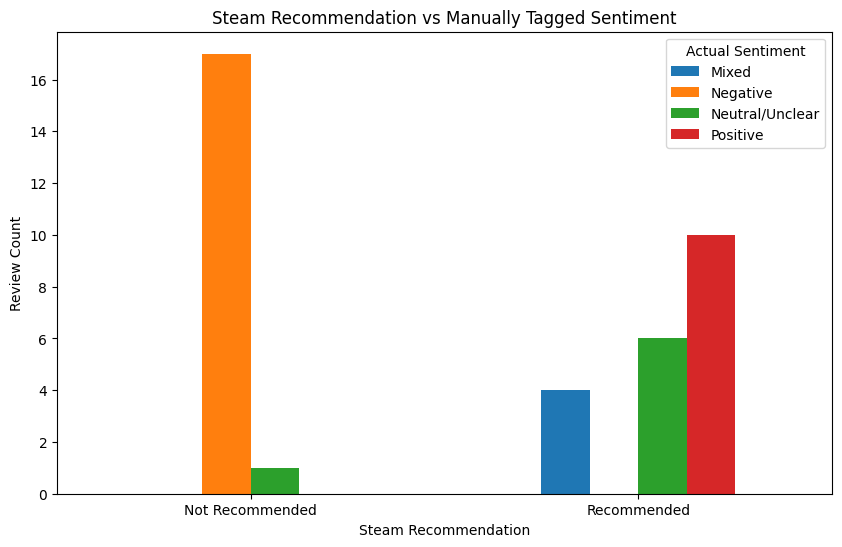

In [7]:
rec_sentiment_counts.plot(kind='bar')
plt.title('Steam Recommendation vs Manually Tagged Sentiment')
plt.xlabel('Steam Recommendation')
plt.ylabel('Review Count')
plt.xticks(rotation=0)
plt.legend(title='Actual Sentiment')
plt.show()

### Reading this table

I use this table to check two things:

- whether `Not Recommended` reviews mostly align with negative sentiment
- whether `Recommended` reviews include mixed, neutral, or unclear text

The second point is important because the project is mostly about nuance, not only obvious contradictions.


## 5. Define mismatch taxonomy

Instead of treating every complaint keyword as a mismatch, the taxonomy compares the Steam label with the manual sentiment label.

The main groups are:

- `Aligned Positive`
- `Aligned Negative`
- `Hard Mismatch`
- `Soft Mismatch`
- `Ambiguous / Low Information`

This keeps the analysis clearer than using raw keywords alone.


mismatch_type
Aligned Negative                             17
Aligned Positive                             10
Ambiguous / Low Information                   7
Soft Mismatch: Recommended but Mixed Text     4
Name: count, dtype: int64

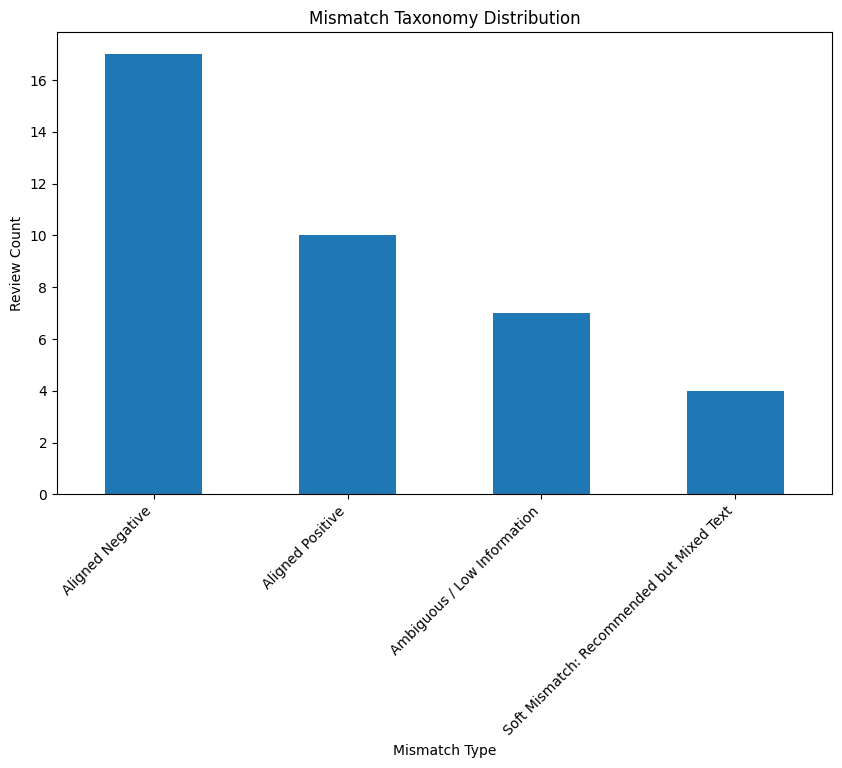

In [8]:
def classify_mismatch(row):
    rec = row['recommendation']
    sent = row['actual_sentiment']

    if rec == 'Recommended' and sent == 'Positive':
        return 'Aligned Positive'

    if rec == 'Not Recommended' and sent == 'Negative':
        return 'Aligned Negative'

    if rec == 'Recommended' and sent == 'Negative':
        return 'Hard Mismatch: Recommended but Negative Text'

    if rec == 'Not Recommended' and sent == 'Positive':
        return 'Hard Mismatch: Not Recommended but Positive Text'

    if rec == 'Recommended' and sent == 'Mixed':
        return 'Soft Mismatch: Recommended but Mixed Text'

    if rec == 'Not Recommended' and sent == 'Mixed':
        return 'Soft Mismatch: Not Recommended but Mixed Text'

    if sent == 'Neutral/Unclear':
        return 'Ambiguous / Low Information'

    return 'Other'


df['mismatch_type'] = df.apply(classify_mismatch, axis=1)

df['is_hard_mismatch'] = df['mismatch_type'].str.startswith('Hard')
df['is_soft_mismatch'] = df['mismatch_type'].str.startswith('Soft')
df['is_ambiguous'] = df['mismatch_type'].str.startswith('Ambiguous')
df['is_mismatch_or_ambiguous'] = (
    df['is_hard_mismatch'] |
    df['is_soft_mismatch'] |
    df['is_ambiguous']
)

mismatch_counts = df['mismatch_type'].value_counts()
display(mismatch_counts)

mismatch_counts.plot(kind='bar')
plt.title('Mismatch Taxonomy Distribution')
plt.xlabel('Mismatch Type')
plt.ylabel('Review Count')
plt.xticks(rotation=45, ha='right')
plt.show()

## 6. Inspect mismatch examples

The counts show the distribution, but the text examples explain what the labels actually mean.

Hard mismatches would be direct contradictions.  
Soft mismatches are less extreme, but often more useful for this project because they show mixed feelings inside a single review.


In [9]:
example_cols = [
    'recommendation',
    'actual_sentiment',
    'mismatch_type',
    'review_category',
    'playtime_hours',
    'analysis_review'
]

print('Hard mismatch examples:')
display(
    df[df['is_hard_mismatch']][example_cols]
)

print('\nSoft mismatch examples:')
display(
    df[df['is_soft_mismatch']][example_cols]
)

print('\nAmbiguous / low-information examples:')
display(
    df[df['is_ambiguous']][example_cols]
)

Hard mismatch examples:


,recommendation,actual_sentiment,mismatch_type,review_category,playtime_hours,analysis_review



Soft mismatch examples:


,recommendation,actual_sentiment,mismatch_type,review_category,playtime_hours,analysis_review
28,Recommended,Mixed,Soft Mismatch: Recommended but Mixed Text,Not My Style / Refund; Mixed Positive,1.9,"I liked this game but I didn't enjoy it enough to keep it. It's fun for people who like solving mystery's and puzzles, Good game just not my style."
35,Recommended,Mixed,Soft Mismatch: Recommended but Mixed Text,Mixed Positive; Positive with Minor Complaint,37.1,amazing game. 10/10. they do need to fix the bugs with the new update
36,Recommended,Mixed,Soft Mismatch: Recommended but Mixed Text,Mixed Positive; Positive with Minor Complaint,25.6,"I'm really enjoying this new update. The diner map is super fun and has a great, creepy vibe. Some people are hating on the update, i might be missing something, but so far everything is awesome. The only real issue I've seen is the fridge door g..."
37,Recommended,Mixed,Soft Mismatch: Recommended but Mixed Text,Mixed Negative; Recommendation Mismatch Candidate,72.7,its an alright game but for me its too clumsy and a bit glitchy so i rarely play it.



Ambiguous / low-information examples:


,recommendation,actual_sentiment,mismatch_type,review_category,playtime_hours,analysis_review
10,Not Recommended,Neutral/Unclear,Ambiguous / Low Information,Feature Request; Low Information,254.9,We need a workshop
23,Recommended,Neutral/Unclear,Ambiguous / Low Information,Meme / Joke Review; Low Information,59.7,*imaginary thumbsup emogi
24,Recommended,Neutral/Unclear,Ambiguous / Low Information,Meme / Joke Review; Low Information,69.1,i got the hantuvirus
27,Recommended,Neutral/Unclear,Ambiguous / Low Information,Meme / Joke Review; Low Information,219.7,My insanity evidence would be UV and no i will not elaborate
29,Recommended,Neutral/Unclear,Ambiguous / Low Information,Meme / Joke Review; Gameplay Anecdote,30.3,Ghost is in room 1. I go room 1. Nothing happen in room 1. Ghost does ghost stuff and crawls out of room 2. I die.
32,Recommended,Neutral/Unclear,Ambiguous / Low Information,Meme / Joke Review; Low Information,44.1,I'm a lot less than just cleaning supplies and a lifeless bimbo body placed under a fabulous wig.
33,Recommended,Neutral/Unclear,Ambiguous / Low Information,Meme / Joke Review; Low Information,5.3,You can roast the ghost


## 7. Primary review category analysis

Manual review categories can contain multiple tags.

For a cleaner summary, this step extracts the first category as the primary category.  
This makes it easier to see the dominant reasons behind positive, negative, mixed, or ambiguous reviews.


primary_category
Genuine Positive              9
Update Backlash               8
Mourning                      6
Meme / Joke Review            6
Mixed Positive                3
Genuine Negative              1
Feature Request               1
Bug / Gameplay Degradation    1
Low Information               1
Not My Style / Refund         1
Mixed Negative                1
Name: count, dtype: int64

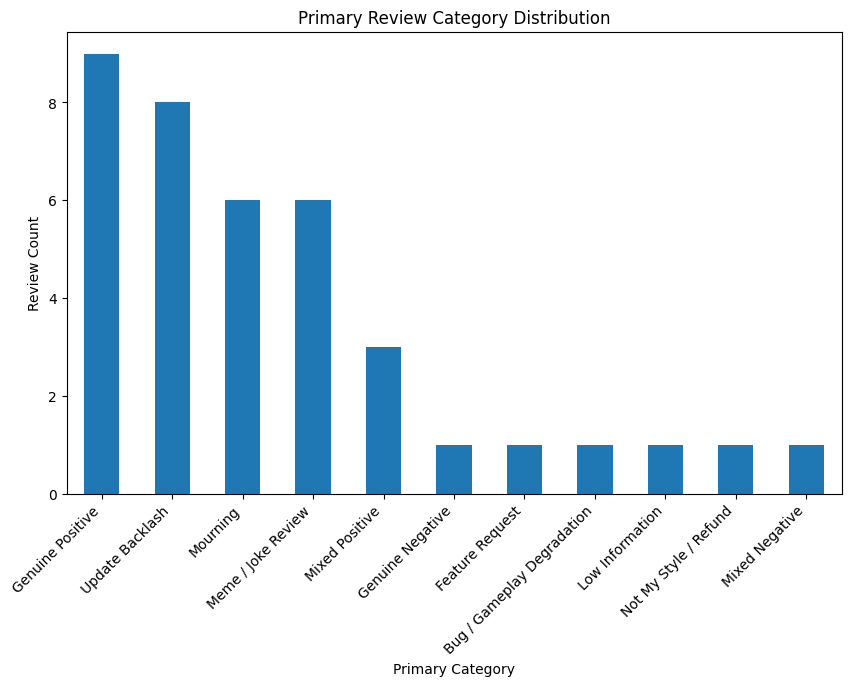

In [10]:
def extract_primary_category(category):
    category = str(category)
    category = category.split(';')[0]
    category = category.split(':')[0]
    return category.strip()


df['primary_category'] = df['review_category'].apply(extract_primary_category)

display(df['primary_category'].value_counts())

df['primary_category'].value_counts().plot(kind='bar')
plt.title('Primary Review Category Distribution')
plt.xlabel('Primary Category')
plt.ylabel('Review Count')
plt.xticks(rotation=45, ha='right')
plt.show()

## 8. Behavioral comparison by mismatch type

After defining mismatch types, this section checks whether the groups differ in behavior.

I compare playtime, review length, helpful votes, and funny votes when those fields are available.  
This helps connect sentiment mismatch with player behavior rather than only text labels.


In [11]:
behavior_cols = [
    'playtime_hours',
    'word_count',
    'helpful_count',
    'funny_count'
]

available_behavior_cols = [col for col in behavior_cols if col in df.columns]

summary_by_mismatch = (
    df.groupby('mismatch_type')[available_behavior_cols]
      .agg(['count', 'mean', 'median'])
      .round(2)
)

display(summary_by_mismatch)

playtime_hours                  \
                                                   count    mean  median   
mismatch_type                                                              
Aligned Negative                                      17  216.45  125.50   
Aligned Positive                                      10  103.90   32.20   
Ambiguous / Low Information                            7   97.59   59.70   
Soft Mismatch: Recommended but Mixed Text              4   34.33   31.35   

                                          word_count                 \
                                               count    mean median   
mismatch_type                                                         
Aligned Negative                                  17  142.29  103.0   
Aligned Positive                                  10   14.10   10.0   
Ambiguous / Low Information                        7   10.29    5.0   
Soft Mismatch: Recommended but Mixed Text          4   30.75   24.0   

                                          helpful_count               \
                                                  count  mean median   
mismatch_type                                                          
Aligned Negative                                     17  3.00    3.0   
Aligned Positive                                     10  0.20    0.0   
Ambiguous / Low Information                           7  0.57    0.0   
Soft Mismatch: Recommended but Mixed Text             4  0.00    0.0   

                                          funny_count               
                                                count  mean median  
mismatch_type                                                       
Aligned Negative                                   17  0.24    0.0  
Aligned Positive                                   10  0.00    0.0  
Ambiguous / Low Information                         7  0.00    0.0  
Soft Mismatch: Recommended but Mixed Text           4  0.00    0.0

C:\Users\ASUS\AppData\Local\Temp\ipykernel_32192\281359985.py:11: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(groups, labels=labels)


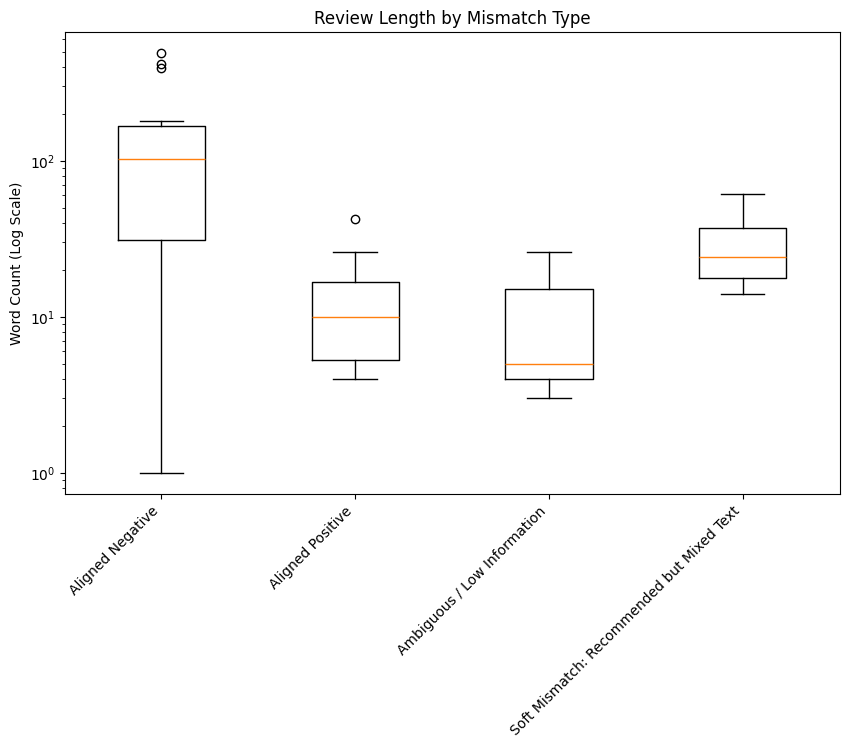

In [12]:
if 'word_count' in df.columns:
    groups = [
        group['word_count'].dropna()
        for _, group in df.groupby('mismatch_type')
    ]
    labels = [
        name
        for name, _ in df.groupby('mismatch_type')
    ]

    plt.boxplot(groups, labels=labels)
    plt.yscale('log')
    plt.title('Review Length by Mismatch Type')
    plt.ylabel('Word Count (Log Scale)')
    plt.xticks(rotation=45, ha='right')
    plt.show()

## 9. Player segment vs actual sentiment

This step checks whether sentiment differs by playtime segment.

If experienced players show more negative or mixed sentiment, it may suggest that long-term experience affects how players evaluate the game.


Player segment vs sentiment counts:


actual_sentiment,Mixed,Negative,Neutral/Unclear,Positive
playtime_segment,,,,
Casual,2,5,2,5
Hardcore,0,4,0,1
New,1,0,1,1
Regular,1,2,2,1
Veteran,0,6,2,2



Player segment-wise percentage:


actual_sentiment,Mixed,Negative,Neutral/Unclear,Positive
playtime_segment,,,,
Casual,14.29,35.71,14.29,35.71
Hardcore,0.00,80.00,0.00,20.00
New,33.33,0.00,33.33,33.33
Regular,16.67,33.33,33.33,16.67
Veteran,0.00,60.00,20.00,20.00


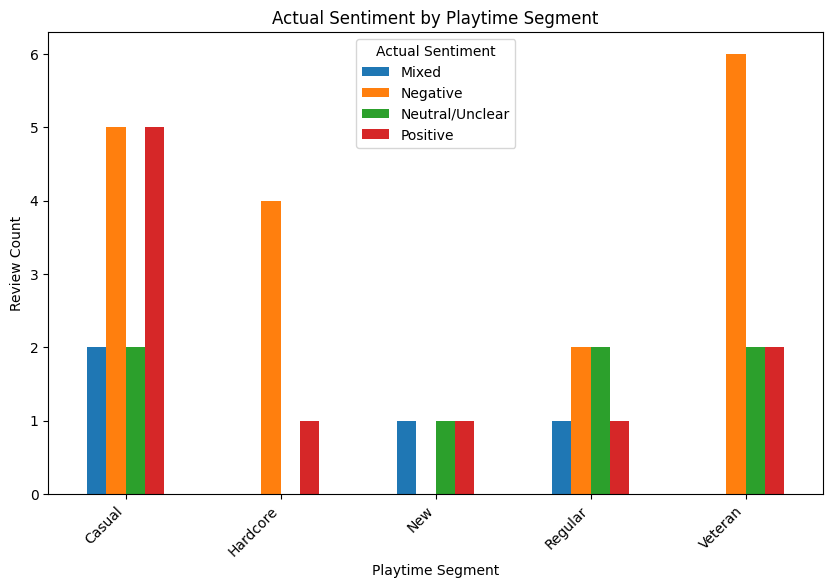

In [13]:
if 'playtime_segment' in df.columns:
    segment_sentiment_counts = pd.crosstab(
        df['playtime_segment'],
        df['actual_sentiment']
    )

    segment_sentiment_pct = pd.crosstab(
        df['playtime_segment'],
        df['actual_sentiment'],
        normalize='index'
    ) * 100

    print('Player segment vs sentiment counts:')
    display(segment_sentiment_counts)

    print('\nPlayer segment-wise percentage:')
    display(segment_sentiment_pct.round(2))

    segment_sentiment_counts.plot(kind='bar')
    plt.title('Actual Sentiment by Playtime Segment')
    plt.xlabel('Playtime Segment')
    plt.ylabel('Review Count')
    plt.xticks(rotation=45, ha='right')
    plt.legend(title='Actual Sentiment')
    plt.show()

## 10. Mourning analysis

Mourning refers to reviews that frame dissatisfaction as loss, nostalgia, or disappointment with the current version of the game.

This is useful because not all negative reviews are simple bug reports.  
Some reviews are emotionally attached to how the game used to feel.


In [14]:
if 'is_mourning_refined' in df.columns:
    print('Mourning flag vs actual sentiment:')
    display(pd.crosstab(df['is_mourning_refined'], df['actual_sentiment']))

    if 'playtime_segment' in df.columns:
        print('\nMourning percentage by playtime segment:')
        display(
            (pd.crosstab(
                df['playtime_segment'],
                df['is_mourning_refined'],
                normalize='index'
            ) * 100).round(2)
        )

    print('\nMourning-like review examples:')
    display(
        df[df['is_mourning_refined']][[
            'recommendation',
            'actual_sentiment',
            'playtime_hours',
            'review_category',
            'analysis_review'
        ]]
    )

Mourning flag vs actual sentiment:


actual_sentiment,Mixed,Negative,Neutral/Unclear,Positive
is_mourning_refined,,,,
False,4,11,7,10
True,0,6,0,0



Mourning percentage by playtime segment:


is_mourning_refined,False,True
playtime_segment,,
Casual,100.0,0.0
Hardcore,80.0,20.0
New,100.0,0.0
Regular,100.0,0.0
Veteran,50.0,50.0



Mourning-like review examples:


,recommendation,actual_sentiment,playtime_hours,review_category,analysis_review
6,Not Recommended,Negative,125.5,Mourning; Update Backlash,Phas had a special jankyness that brought a little charm to the game. Only thing they ever needed to fix was loading screen bugs and ghosts not functioning properly. The community asks for workshop or for more maps that make sense at the very lea...
7,Not Recommended,Negative,162.8,Update Backlash; Developer Criticism,So were supposed to get character customization and yet we only got a bunch of random assets thrown together. The game has been out for over a half a decade and yet it feels more and more early access as more updates gets out. just revert back to...
8,Not Recommended,Negative,777.7,Mourning; Bug / Gameplay Degradation,"This was a great game, an ""indie"" that made it big. The last update(s) have made it virtually unplayable. The UI is virtually unusable, the performance is now a stuttery mess, and all the ""indie janky charm"" has been replaced by ""failed realism""...."
9,Not Recommended,Negative,215.6,Mourning; Update Backlash,"this game was great until the character update please revert :D or at least fix all the issues its caused, like the delay on almost everything and the weird new animations."
16,Not Recommended,Negative,101.0,Mourning; Update Backlash,"Multi-million dollars studio that acts aimlessly with their golden goose, lack of consistent updates and very terrible decisions in recent times. They killed my enjoyement of the game with the most recent animation update and their response to th..."
17,Not Recommended,Negative,286.1,Mourning; Update Backlash,"TLDR; New gamers, I urge you not to buy this game. Do not throw good money after bad. The majority of good reviews for this game are for an archived version of ""Phasmophobia"" which is longer exists and/or in not available after 05/05/26. After th..."


## 11. Update / bug language vs actual sentiment

This section checks whether update-related and bug/degradation signals line up with manual sentiment.

The goal is to see whether these keyword features are useful supporting evidence for negative or mixed review categories.


In [15]:
keyword_cols = [
    'contains_update_keyword_refined',
    'contains_bug_or_degradation_keyword',
    'contains_positive_emotion',
    'contains_negative_emotion'
]

for col in keyword_cols:
    if col in df.columns:
        print(f'\n{col} vs actual_sentiment')
        display(pd.crosstab(df[col], df['actual_sentiment']))
        display((pd.crosstab(df[col], df['actual_sentiment'], normalize='index') * 100).round(2))


contains_update_keyword_refined vs actual_sentiment


actual_sentiment,Mixed,Negative,Neutral/Unclear,Positive
contains_update_keyword_refined,,,,
False,2,2,7,9
True,2,15,0,1


actual_sentiment,Mixed,Negative,Neutral/Unclear,Positive
contains_update_keyword_refined,,,,
False,10.00,10.00,35.0,45.00
True,11.11,83.33,0.0,5.56



contains_bug_or_degradation_keyword vs actual_sentiment


actual_sentiment,Mixed,Negative,Neutral/Unclear,Positive
contains_bug_or_degradation_keyword,,,,
False,1,5,7,10
True,3,12,0,0


...

actual_sentiment,Mixed,Negative,Neutral/Unclear,Positive
contains_positive_emotion,,,,
False,1,6,7,0
True,3,11,0,10


actual_sentiment,Mixed,Negative,Neutral/Unclear,Positive
contains_positive_emotion,,,,
False,7.14,42.86,50.0,0.00
True,12.50,45.83,0.0,41.67



contains_negative_emotion vs actual_sentiment


actual_sentiment,Mixed,Negative,Neutral/Unclear,Positive
contains_negative_emotion,,,,
False,4,4,7,10
True,0,13,0,0


actual_sentiment,Mixed,Negative,Neutral/Unclear,Positive
contains_negative_emotion,,,,
False,16.0,16.0,28.0,40.0
True,0.0,100.0,0.0,0.0


## 12. Representative examples

These examples are useful for checking whether the taxonomy makes sense when reading the actual review text.

I use them as qualitative evidence for the dashboard and README, but the main analysis still comes from the summarized counts above.


In [16]:
def show_examples(title, condition, n=3):
    print('\n' + '=' * 80)
    print(title)
    print('=' * 80)
    subset = df[condition].head(n)
    for idx, row in subset.iterrows():
        print(f"\nRecommendation: {row['recommendation']}")
        print(f"Actual Sentiment: {row['actual_sentiment']}")
        print(f"Category: {row['review_category']}")
        if 'playtime_hours' in row:
            print(f"Playtime: {row['playtime_hours']} hours")
        print('Review preview:')
        print(str(row['analysis_review'])[:700])
        print('-' * 80)

show_examples(
    'Aligned Negative / Update Backlash Examples',
    df['mismatch_type'].eq('Aligned Negative'),
    n=3
)

show_examples(
    'Soft Mismatch Examples',
    df['is_soft_mismatch'],
    n=4
)

show_examples(
    'Ambiguous / Meme / Low Information Examples',
    df['is_ambiguous'],
    n=4
)


Aligned Negative / Update Backlash Examples

Recommendation: Not Recommended
Actual Sentiment: Negative
Category: Update Backlash; Sarcasm / Bug Complaint
Playtime: 77.1 hours
Review preview:
Rushed out a buggy and broken update so they could do an Alan Wake (2) collab. Marvelous.
--------------------------------------------------------------------------------

Recommendation: Not Recommended
Actual Sentiment: Negative
Category: Update Backlash; Mourning-lite
Playtime: 23.5 hours
Review preview:
The latest update has ruined the experience for me ( bendy back gone)
--------------------------------------------------------------------------------

Recommendation: Not Recommended
Actual Sentiment: Negative
Category: Update Backlash; Developer Criticism
Playtime: 65.4 hours
Review preview:
This last update was a mess. It's been on the roadmap since 2022 yet the devs keep saying it was rushed at every turn. An update that is a flawed mess of so called features. If you like awful AI like ani

## 13. Export analysis-ready tagged dataset

After the mismatch taxonomy and primary category fields are added, the dataset is saved into `data/processed/`.

This output keeps the manual labels together with the new analysis fields, so it can be reused by later notebooks.


In [17]:
output_path = DATA_PROCESSED / "manual_tagging_analysis_ready.csv"

df.to_csv(output_path, index=False, encoding="utf-8-sig")

print(f"Saved analysis-ready tagged dataset to: {output_path}")
print("Rows:", len(df))
print("Columns:", len(df.columns))


Saved analysis-ready tagged dataset to: ..\data\processed\manual_tagging_analysis_ready.csv
Rows: 38
Columns: 26


## 14. Notes from this analysis

After running the notebook, the main things to check are:

1. How strongly `Not Recommended` reviews align with negative sentiment.
2. Whether `Recommended` reviews contain mixed or unclear text.
3. Whether soft mismatch appears more often than hard contradiction.
4. Whether mourning, update backlash, or bug/degradation language explains negative reviews.
5. Whether playtime or review length differs across mismatch groups.

These notes should be treated as early exploratory findings because this notebook uses the pilot tagged sample.
